# Python with MongoDB

Helpful learning resources: https://www.tutorialspoint.com/mongodb/index.htm

## Libraries and Settings

In [2]:
"""Connect to MongoDB, insert restaurant data, run queries, and visualize results."""   #Beschreibung des Programms

# Libraries                                                                             #Benötigte Bibliotheken

import json                                                                             #JSON-Dateien lesen und verarbeiten
import os                                                                               #Funktionen für Betriebssystem und Dateipfade
import platform                                                                         #Informationen über das Betriebssystem abrufen
import warnings                                                                         #Warnmeldungen steuern
from datetime import datetime                                                           #Datum und Uhrzeit verarbeiten
from platform import python_version                                                     #Installierte Python-Version auslesen

import matplotlib.pyplot as plt                                                         #Diagramme und Visualisierungen erstellen
import pandas as pd                                                                     #Daten in Tabellenform analysieren und bearbeiten
from pymongo import MongoClient                                                         #Verbindung zu MongoDB herstellen
from pymongo.errors import PyMongoError                                                 #MongoDB-Fehler abfangen

# Settings  
warnings.filterwarnings("ignore")                                                       #Warnmeldungen ausblenden

# Use dark background for plots                                                         #Dunklen Hintergrund für Diagramme verwenden
plt.style.use("dark_background")                                                        #Matplotlib auf Dark Mode setzen

# Current working directory                                                             #Aktuelles Arbeitsverzeichnis anzeigen
print(os.getcwd())                                                                      #Gibt den Ordner aus, in dem das Python-Programm aktuell arbeitet

/workspace


## Connect to the MongoDB server and list databases

In [3]:
# Connect to the MongoDB server                         #Verbindung zum MongoDB-Server herstellen
client = MongoClient("mongodb://mongo:27017/")          #Verbindung zu MongoDB auf Host "mongo" und Port 27017 aufbauen

# List databases                                        #Verfügbare Datenbanken auflisten
databases = client.list_database_names()                #Namen aller vorhandenen MongoDB-Datenbanken abrufen
print("Connected to MongoDB. Databases:", databases)    #Erfolgreiche Verbindung und Datenbanken ausgeben

Connected to MongoDB. Databases: ['admin', 'car_database', 'config', 'local']


## Read and insert data

In [4]:
# Create / access the specific database and collection                      #Bestimmte Datenbank und Collection erstellen bzw. darauf zugreifen

db = client["restaurant_database"]                                          #Auf die Datenbank "restaurant_database" zugreifen bzw. sie bei Bedarf anlegen
collection = db["restaurant_collection"]                                    #Auf die Collection "restaurant_collection" zugreifen bzw. sie bei Bedarf anlegen

# Read data from JSON file  # Daten aus einer JSON-Datei einlesen

with open(
    "/workspace/data/restaurant_data.json", "r", encoding="utf-8"           #JSON-Datei im Lesemodus mit UTF-8-Encoding öffnen
) as file:
    example_data = json.load(file)                                          #Inhalt der JSON-Datei als Python-Datenstruktur laden

# Insert data into the collection (similar to tables in an SQL database)    #Daten in die Collection einfügen

try:  # Versuchen, die Daten einzufügen
    insert_result = collection.insert_many(example_data)                    #Mehrere Dokumente gleichzeitig in MongoDB einfügen
    print("Inserted documents to MongoDB")                                  #Erfolgsmeldung ausgeben
except PyMongoError as error:                                               #MongoDB-Fehler abfangen
    print(f"Insert error: {error}")                                         #Fehlermeldung ausgeben

Inserted documents to MongoDB


## Define a query using MongoDB Query Language (MQL)

In [5]:
# Function to query the data  # Funktion definieren, um Daten aus MongoDB abzufragen

def query_collection(database_name, coll_name, mongo_query, mongo_client=client):   #Datenbank, Collection, Query und MongoDB-Client als Parameter übergeben
    """Run a find query against a MongoDB collection and return the results."""     #Beschreibung der Funktion
    if mongo_client:                                                                #Prüfen, ob ein MongoDB-Client vorhanden ist
        database = mongo_client[database_name]                                      #Gewünschte Datenbank auswählen
        coll = database[coll_name]                                                  #Gewünschte Collection auswählen
        query_results = list(coll.find(mongo_query))                                #Query ausführen und Ergebnisse als Liste speichern
        return query_results                                                        #Gefundene Dokumente zurückgeben
    return []                                                                       #Leere Liste zurückgeben, falls kein MongoDB-Client vorhanden ist

# Define a query with multiple conditions                                           
query = {                                                                           #Query als Dictionary erstellen
    "properties.addr:city": {"$in": ["Zürich", "Winterthur"]},                      #Nur Restaurants aus Zürich oder Winterthur auswählen
    "properties.amenity": "restaurant",                                             #Nur Einträge auswählen, deren Typ "restaurant" ist
    "properties.cuisine": {"$in": ["burger", "pizza"]},                             #Nur Restaurants mit Burger- oder Pizza-Küche auswählen
}

# Execute the query and fetch the results                                           #Query ausführen und Ergebnisse abrufen
results = query_collection(                                                         #Zuvor definierte Funktion aufrufen
    "restaurant_database",                                                          #Datenbank angeben
    "restaurant_collection",                                                        #Collection angeben
    query,                                                                          #Definierte MongoDB-Abfrage übergeben
)

print("Query result:")                                                              #Überschrift für die Ausgabe anzeigen
for result in results:                                                              #Alle gefundenen Dokumente durchlaufen
    print(result)                                                                   #Jedes gefundene Dokument ausgeben

# Convert the results into a Pandas DataFrame 
data = []                                                                           #Leere Liste für die aufbereiteten Daten erstellen

for result in results:                                                              #Alle gefundenen Dokumente durchlaufen
    properties = result["properties"]                                               #Verschachteltes "properties"-Dictionary aus dem Dokument holen
    data.append(  # Gewünschte Werte als neues Dictionary zur Liste hinzufügen
        {
            "street": properties.get("addr:street"),                                #Strassenname auslesen
            "housenumber": properties.get("addr:housenumber"),                      #Hausnummer auslesen
            "postcode": properties.get("addr:postcode"),                            #Postleitzahl auslesen
            "city": properties.get("addr:city"),                                    #Stadt auslesen
            "amenity": properties.get("amenity"),                                   #Art des Betriebs auslesen
            "cuisine": properties.get("cuisine"),                                   #Küchenart auslesen
        }
    )

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(data)                                                             #Liste von Dictionaries in eine Tabelle umwandeln

# Display the DataFrame
df.head()                                                                           #Die ersten fünf Zeilen der Tabelle anzeigen

Query result:
{'_id': ObjectId('6ab8560b344cea3d3020ec18'), 'type': 'Feature', 'properties': {'@id': 'way/39374814', 'addr:city': 'Winterthur', 'addr:housenumber': '40', 'addr:postcode': '8400', 'addr:street': 'Lindstrasse', 'amenity': 'restaurant', 'building': 'apartments', 'building:levels': '4', 'capacity': '70', 'check_date:opening_hours': '2022-03-21', 'cuisine': 'pizza', 'delivery': 'no', 'name': 'Friedtal', 'opening_hours': 'Mo-Fr 08:30-24:00; Sa 10:00-24:00', 'roof:levels': '1', 'roof:shape': 'flat', 'takeaway': 'no'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[8.7231586, 47.5094355], [8.7233191, 47.509261], [8.7234407, 47.5093147], [8.7234999, 47.5093747], [8.7234382, 47.5094314], [8.7233605, 47.5093947], [8.7232812, 47.5094856], [8.7231586, 47.5094355]]]}, 'id': 'way/39374814'}
{'_id': ObjectId('6ab8560b344cea3d3020f923'), 'type': 'Feature', 'properties': {'@id': 'node/266864505', 'addr:city': 'Zürich', 'addr:housenumber': '30', 'addr:postcode': '8600', 'addr:street': 

,street,housenumber,postcode,city,amenity,cuisine
0,Lindstrasse,40,8400,Winterthur,restaurant,pizza
1,Zürichstrasse,30,8600,Zürich,restaurant,pizza
2,Limmatquai,16,8001,Zürich,restaurant,pizza
3,Waaggasse,5,8001,Zürich,restaurant,pizza
4,Regensbergstrasse,188,8050,Zürich,restaurant,pizza


## Define a query to aggregate the data using MongoDB Query Language (MQL)

In [6]:
# Function to aggregate the number of restaurants by cuisine and city           #Funktion definieren, um Restaurants nach Küche und Stadt zu gruppieren und zu zählen
def aggregate_restaurants_by_cuisine_and_city(                                  #Aggregationsfunktion definieren
    database_name, coll_name, mongo_client=client                               #Datenbankname, Collectionname und MongoDB-Client als Parameter übergeben
):
    """Aggregate restaurant counts grouped by city and cuisine."""              #Beschreibung der Funktion
    database = mongo_client[database_name]                                      #Gewünschte Datenbank auswählen
    coll = database[coll_name]                                                  #Gewünschte Collection auswählen

    pipeline = [                                                                #MongoDB-Aggregationspipeline definieren
        {
            "$match": {                                                         #Dokumente anhand bestimmter Kriterien filtern
                "properties.addr:city": {                                       #Feld für die Stadt auswählen
                    "$in": ["Zürich", "Winterthur"]                             #Nur Restaurants aus Zürich oder Winterthur berücksichtigen
                },
                "properties.cuisine": {"$in": ["burger", "pizza"]},             #Nur Burger- oder Pizza-Restaurants berücksichtigen
            }
        },
        {
            "$group": {                                                         #Gefilterte Dokumente gruppieren
                "_id": {                                                        #Gruppierungsschlüssel definieren
                    "city": "$properties.addr:city",                            #Nach Stadt gruppieren
                    "cuisine": "$properties.cuisine",                           #Zusätzlich nach Küchenart gruppieren
                },
                "count": {"$sum": 1},                                           #Anzahl Restaurants pro Gruppe zählen
            }
        },
        {"$sort": {"count": -1}},                                               #Gruppen absteigend nach Anzahl Restaurants sortieren
    ]

    aggregation_results = list(coll.aggregate(pipeline))                        #Aggregationspipeline ausführen und Ergebnisse als Liste speichern
    return aggregation_results                                                  #Aggregationsergebnisse zurückgeben


# Execute the aggregation query                                                 #Aggregationsabfrage ausführen
results = aggregate_restaurants_by_cuisine_and_city(                            #Aggregationsfunktion aufrufen
    "restaurant_database",                                                      #Datenbank angeben
    "restaurant_collection",                                                    #Collection angeben
)

print("Query result:")                                                          #Überschrift für die Ausgabe anzeigen

for result in results:                                                          #Alle Aggregationsergebnisse durchlaufen
    print(result)                                                               #Jedes Ergebnis ausgeben


# Convert the results into a Pandas DataFrame
df = pd.DataFrame(results)                                                      #Liste der Ergebnisse als Tabelle darstellen


# Normalize the '_id' field to separate columns  
df = pd.concat(                                                                 #Mehrere DataFrames zu einem DataFrame zusammenfügen
    [df.drop(["_id"], axis=1), df["_id"].apply(pd.Series)],                     #"_id" entfernen und dessen Inhalte "city" und "cuisine" als eigene Spalten hinzufügen
    axis=1,                                                                     #DataFrames spaltenweise zusammenfügen
)


# Display the DataFrame  
df                                                                              #Gesamten DataFrame ausgeben

Query result:
{'_id': {'city': 'Zürich', 'cuisine': 'pizza'}, 'count': 27}
{'_id': {'city': 'Zürich', 'cuisine': 'burger'}, 'count': 19}
{'_id': {'city': 'Winterthur', 'cuisine': 'pizza'}, 'count': 8}
{'_id': {'city': 'Winterthur', 'cuisine': 'burger'}, 'count': 3}


,count,city,cuisine
0,27,Zürich,pizza
1,19,Zürich,burger
2,8,Winterthur,pizza
3,3,Winterthur,burger


## Make bar chart from results

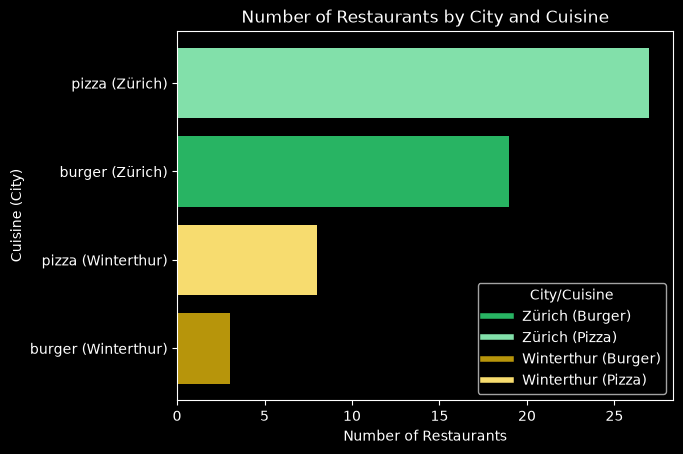

In [7]:
# Sort values in ascending order                            
df = df.sort_values(by="count", ascending=True)                 #Kleinste Anzahl zuerst anzeigen

# Define colors for each city and cuisine combination       
colors = {                                                      #Dictionary mit Farben erstellen
    ("Zürich", "burger"): "#28b463",                          #Farbe für Burger-Restaurants in Zürich
    ("Zürich", "pizza"): "#82e0aa",                           #Farbe für Pizza-Restaurants in Zürich
    ("Winterthur", "burger"): "#b7950b",                      #Farbe für Burger-Restaurants in Winterthur
    ("Winterthur", "pizza"): "#f7dc6f",                       #Farbe für Pizza-Restaurants in Winterthur
}

# Create a bar chart 
fig, ax = plt.subplots()                                        #Neue Matplotlib-Figur und Achse erzeugen

# Plot data
for city in df["city"].unique():                                #Jede vorhandene Stadt einzeln durchlaufen
    city_data = df[df["city"] == city]                          #Nur Daten der aktuellen Stadt auswählen

    ax.barh(                                                    #Horizontales Balkendiagramm zeichnen
        city_data["cuisine"] + " (" + city + ")",               #Beschriftung aus Küchenart und Stadt zusammensetzen
        city_data["count"],                                     #Anzahl Restaurants als Balkenlänge verwenden
        color=[                                                 #Farbe für jeden Balken festlegen
            colors[(city, cuisine)]                             #Passende Farbe anhand von Stadt und Küchenart auswählen
            for cuisine in city_data["cuisine"]                 #Alle Küchenarten der aktuellen Stadt durchlaufen
        ],
        label=city,                                             #Stadt als Label hinterlegen
    )

# Add labels and title
ax.set_xlabel("Number of Restaurants")                          #X-Achse mit Anzahl Restaurants beschriften
ax.set_ylabel("Cuisine (City)")                                 #Y-Achse mit Küchenart und Stadt beschriften
ax.set_title("Number of Restaurants by City and Cuisine")       #Titel des Diagramms setzen

# Create custom legend
handles = [                                                     #Liste mit Legendeneinträgen erstellen
    plt.Line2D(                                                 #Manuellen Legendeneintrag erzeugen
        [0], [0], color=list(colors.values())[0], lw=4,         #Farbe für Zürich Burger festlegen
        label="Zürich (Burger)",                                #Bezeichnung des Legendeneintrags
    ),
    plt.Line2D(                                                 #Manuellen Legendeneintrag erzeugen
        [0], [0], color=list(colors.values())[1], lw=4,         #Farbe für Zürich Pizza festlegen
        label="Zürich (Pizza)",                                 #Bezeichnung des Legendeneintrags
    ),
    plt.Line2D(                                                 #Manuellen Legendeneintrag erzeugen
        [0], [0], color=list(colors.values())[2], lw=4,         #Farbe für Winterthur Burger festlegen
        label="Winterthur (Burger)",                            #Bezeichnung des Legendeneintrags
    ),
    plt.Line2D(                                                 #Manuellen Legendeneintrag erzeugen
        [0], [0], color=list(colors.values())[3], lw=4,         #Farbe für Winterthur Pizza festlegen
        label="Winterthur (Pizza)",                             #Bezeichnung des Legendeneintrags
    ),
]

ax.legend(handles=handles, title="City/Cuisine")                #Eigene Legende zum Diagramm hinzufügen

# Show the plot 
plt.show()                                                      #Fertiges Diagramm ausgeben

## Drop defined collections and databases

In [ ]:
# List databases

databases = client.list_database_names()                                        # Namen aller aktuell vorhandenen Datenbanken abrufen
print("Connected to MongoDB. Databases:", databases)                            #Verbindung und Datenbanknamen ausgeben

# Drop the defined collection and database if they exist 

DB_NAME = "restaurant_database"                                                 #Namen der zu löschenden Datenbank definieren
COLLECTION_NAME = "restaurant_collection"                                       #Namen der zu löschenden Collection definieren

db = client[DB_NAME]                                                            #Auf die gewünschte Datenbank zugreifen

if COLLECTION_NAME in db.list_collection_names():                               #Prüfen, ob die Collection existiert
    db.drop_collection(COLLECTION_NAME)                                         #Collection aus der Datenbank löschen
    print(  # Erfolgsmeldung ausgeben
        f"Collection '{COLLECTION_NAME}' dropped from database "                #Name der gelöschten Collection ausgeben
        f"'{DB_NAME}'."                                                         #Name der zugehörigen Datenbank ausgeben
    )
else:                                                                           #Falls die Collection nicht existiert
    print(                                                                      #Entsprechende Meldung ausgeben
        f"Collection '{COLLECTION_NAME}' does not exist in database "           #Hinweis, dass die Collection nicht vorhanden ist
        f"'{DB_NAME}'."                                                         #Name der geprüften Datenbank ausgeben
    )

# Drop the database

if DB_NAME in databases:                                                        #Prüfen, ob die Datenbank existiert
    client.drop_database(DB_NAME)                                               #Gesamte Datenbank löschen
    print(f"Database '{DB_NAME}' dropped.")                                     #Erfolgsmeldung ausgeben
else:                                                                           #Falls die Datenbank nicht existiert
    print(f"Database '{DB_NAME}' does not exist.")                              #Entsprechende Meldung ausgeben

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [ ]:
print("-" * 35)
print(os.name.upper())
print(platform.system(), "|", platform.release())
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version:", python_version())
print("-" * 35)